# Motif-Based Boundary Detection

This notebook demonstrates `formula_detection.motif`, which generalises the pairwise phrase co-occurrence test from `PhraseCooccurrenceIndex` to **ordered, multi-phrase motifs** &mdash; sets of 2&ndash;4 candidate phrases that recur together, in a consistent order, within a bounded span of the text stream.

The key idea: when a set of phrases reliably co-occurs in a tight span with a low-entropy (near-fixed) internal order, each occurrence of that set is itself a strong candidate for a document or document-element boundary &mdash; far more specific than a single phrase-pair transition, because it requires several independent pieces of evidence to align at once.

We also demonstrate `classify_relation`, which characterises how two motifs relate positionally across the stream: sequential/adjacent, nested, overlapping (sharing a phrase), or unrelated.

In [1]:
%reload_ext autoreload
%autoreload 2

import random

import matplotlib.pyplot as plt

from formula_detection.search import FormulaSearch
from formula_detection.phrase_cooccurrence import PhraseCooccurrenceIndex
from formula_detection.motif import PhraseMotifIndex, classify_relation
from formula_detection.boundary import BoundaryDetector

import csv
import gzip
import re
from collections import Counter

from formula_detection.search import FormulaSearch
from formula_detection.phrase_cooccurrence import PhraseCooccurrenceIndex
from formula_detection.motif import PhraseMotifIndex
from formula_detection.boundary import BoundaryDetector


def tokenize(text):
    return TOKEN_RE.findall(text.lower())


def load_rows(path):
    rows = []
    with gzip.open(path, 'rt', encoding='utf-8') as f:
        for row in csv.DictReader(f, delimiter='\t'):
            rows.append(row)
    return rows


def build_stream_and_ground_truth(rows):
    documents = []  # one per paragraph, for FormulaSearch
    flat_stream = []
    para_starts = []
    res_starts = []
    prev_res_id = None
    offset = 0
    for row in rows:
        tokens = tokenize(row['text'])
        documents.append(tokens)
        para_starts.append(offset)
        if row['resolution_id'] != prev_res_id:
            res_starts.append(offset)
            prev_res_id = row['resolution_id']
        flat_stream.extend(tokens)
        offset += len(tokens)
    return documents, flat_stream, para_starts, res_starts


def evaluate(detected, true_points, tolerance):
    if not detected:
        return 0.0, 0.0, 0.0
    matched_true = sum(1 for t in true_points if any(abs(d - t) <= tolerance for d in detected))
    matched_detected = sum(1 for d in detected if any(abs(d - t) <= tolerance for t in true_points))
    recall = matched_true / len(true_points)
    precision = matched_detected / len(detected)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1



## 1. Building a synthetic corpus with internal document structure

We generate 60 documents of three types (`alpha`, `beta`, `gamma`), each built from four formula phrases: an opening, two body phrases, and a closing. `alpha` documents additionally embed a small **nested** two-phrase "stamp" formula (`stamp left` ... `stamp right`) about half the time, positioned between the two body phrases &mdash; simulating a recurring sub-element inside a larger document.

Documents are separated by a generous filler gap. As established earlier when tuning community detection, the window used for co-occurrence/motif mining must be **smaller than the typical gap between documents** but **larger than the span of one document's formula** &mdash; otherwise windows blend adjacent documents together. We size the gap (45 tokens) comfortably larger than the longest document (about 31 tokens) so a window of 35 cleanly captures within-document structure only.

In [2]:
DATA_PATH = '../data/resolution_paragraphs/paragraphs-3823.tsv.gz'
TOKEN_RE = re.compile(r"[A-Za-zÀ-ÿ]+")


print('Loading data...')
rows = load_rows(DATA_PATH)
documents, flat_stream, para_starts, res_starts = build_stream_and_ground_truth(rows)
print(f'{len(rows)} paragraphs, {len(set(r["resolution_id"] for r in rows))} resolutions, '
      f'{len(flat_stream)} tokens')
print(f'{len(para_starts)} true paragraph starts, {len(res_starts)} true resolution starts')



Loading data...
2909 paragraphs, 2296 resolutions, 449905 tokens
2909 true paragraph starts, 2296 true resolution starts


In [9]:
print('\nRunning FormulaSearch to discover candidate phrases...')
fs = FormulaSearch(documents, min_term_freq=5, skip_size=2,
                   min_cooc_freq=5, max_min_term_frac=0.05, report=False)

phrase_freq = Counter()
extractor = fs.extract_phrases('long_phrases', min_neighbour_cooc=1, max_docs=None)
extractor = fs.extract_phrases('sub_phrases', min_phrase_length=3, max_phrase_length=6,
                                min_neighbour_cooc=1, max_docs=None)
for match in extractor:
    phrase_freq[match.candidate_phrase.phrase_string] += 1

print(f'{len(phrase_freq)} distinct candidate phrases discovered')
print('\nTop 30 by frequency:')
for phrase, freq in phrase_freq.most_common(30):
    print(f'  {freq: >5}  {phrase}')




Running FormulaSearch to discover candidate phrases...
1. Iterating over sentences to calculate term frequencies
    full collection size (tokens): 449,905
    full lexicon size (types): 21,185
    minimum term frequency: 5
    minimum frequency lexicon size: 4,881
2. Iterating over sentences to calculate the co-occurrence frequencies
docs: 2,909	num_words: 449,905	num_coocs: 1,195,278	num distinct coocs: 226,955
    co-occurrence index size: 226,955
Minimum co-occurrence frequency: 5
141256 distinct candidate phrases discovered

Top 30 by frequency:
    839  op gedelibereert zynde is goedgevonden en
    839  gedelibereert zynde is goedgevonden en verstaan
    836  waar op gedelibereert zynde is goedgevonden
    835  waar op geen resolutie is gevallen
    720  advertentie waar op geen resolutie is
    718  houdende advertentie waar op geen resolutie
    674  zynde is goedgevonden en verstaan dat
    635  maand houdende advertentie waar op geen
    508  ontfangen een missive van den he

In [10]:
# Deduplicate near-identical sliding-window n-grams of the same underlying
# formula (e.g. "...op gedelibereert zynde is..." vs "...gedelibereert zynde
# is goedgevonden..."): process by frequency descending (most informative
# first) and drop a candidate only if it's a substring of one already kept.
n_paragraphs = len(documents)
max_freq_ratio = 1.2  # exclude phrases that recur on average >1.2x per paragraph
pool = [(p, f) for p, f in phrase_freq.most_common(300) if f / n_paragraphs <= max_freq_ratio]
kept = []
for phrase, freq in pool:
    if any(phrase in k for k in kept):
        continue
    kept.append(phrase)
    if len(kept) >= 60:
        break
candidate_phrases = kept
print(f'\n{len(candidate_phrases)} candidate phrases after dedup/frequency-ratio filtering:')
for p in candidate_phrases:
    print(f'  ({phrase_freq[p]: >4})  {p}')




60 candidate phrases after dedup/frequency-ratio filtering:
  ( 839)  op gedelibereert zynde is goedgevonden en
  ( 839)  gedelibereert zynde is goedgevonden en verstaan
  ( 836)  waar op gedelibereert zynde is goedgevonden
  ( 835)  waar op geen resolutie is gevallen
  ( 720)  advertentie waar op geen resolutie is
  ( 718)  houdende advertentie waar op geen resolutie
  ( 674)  zynde is goedgevonden en verstaan dat
  ( 635)  maand houdende advertentie waar op geen
  ( 508)  ontfangen een missive van den heere
  ( 427)  den deeser loopende maand houdende advertentie
  ( 419)  loopende maand houdende advertentie waar op
  ( 415)  deeser loopende maand houdende advertentie waar
  ( 408)  haar hoog mog resolutie van den
  ( 365)  goedgevonden en verstaan dat copie van
  ( 363)  van sijne majesteit den koning van
  ( 361)  en verstaan dat copie van de
  ( 342)  het hof van sijne majesteit den
  ( 340)  aan het hof van sijne majesteit
  ( 339)  is goedgevonden en verstaan dat copie
  ( 335)

## 2. Getting phrase positions from PhraseCooccurrenceIndex

`PhraseMotifIndex` operates entirely on `phrase_positions` &mdash; the per-phrase sorted offset lists already collected by `PhraseCooccurrenceIndex.index_stream`. No second pass over the token stream is needed for motif mining itself.

In [11]:
print('\nBuilding phrase co-occurrence index over the flat stream...')
cooc_index = PhraseCooccurrenceIndex(candidate_phrases, windows=[300])
cooc_index.index_stream(flat_stream)
print('Phrase frequencies in stream:')
for phrase, freq in cooc_index.phrase_freq.most_common(15):
    print(f'  {freq: >5}  {phrase}')




Building phrase co-occurrence index over the flat stream...
Phrase frequencies in stream:
    839  op gedelibereert zynde is goedgevonden en
    839  gedelibereert zynde is goedgevonden en verstaan
    836  waar op gedelibereert zynde is goedgevonden
    835  waar op geen resolutie is gevallen
    720  advertentie waar op geen resolutie is
    718  houdende advertentie waar op geen resolutie
    674  zynde is goedgevonden en verstaan dat
    635  maand houdende advertentie waar op geen
    508  ontfangen een missive van den heere
    427  den deeser loopende maand houdende advertentie
    419  loopende maand houdende advertentie waar op
    415  deeser loopende maand houdende advertentie waar
    408  haar hoog mog resolutie van den
    365  goedgevonden en verstaan dat copie van
    363  van sijne majesteit den koning van


In [12]:
para_lengths = [len(d) for d in documents]
para_lengths.sort()
median_para_len = para_lengths[len(para_lengths) // 2]
window = max(30, median_para_len)
print(f'\nMedian paragraph length: {median_para_len} tokens -> using manual window={window} '
      f'("auto" mode breaks down on this corpus, see notes)')



Median paragraph length: 67 tokens -> using manual window=67 ("auto" mode breaks down on this corpus, see notes)


## 3. Mining motifs

We mine sets of size 2&ndash;4 with a window of 35 tokens (just under the inter-document gap of 45, comfortably above the longest single document). `min_lift=2.0` keeps only sets that co-occur at least twice as often as expected under independence.

In [13]:
motif_index = PhraseMotifIndex(cooc_index.phrase_positions, window=window,
                               min_set_size=2, max_set_size=4,
                               min_support=2, min_lift=5.0)
motifs = motif_index.mine_motifs()
print(f'{len(motifs)} motifs found')
motifs.sort(key=lambda m: -m.lift)
for m in motifs[:15]:
    print(' ', m)
# keep only the highest-lift motifs as boundary evidence: with thousands
# of mined motifs (many near-duplicate subsets of the same long formula),
# using all of them is both redundant and -- more importantly -- makes
# detect_boundaries' O(n*k) suppression loop too slow to be usable.
motifs = motifs[:40]



PhraseMotifIndex.mine_motifs - skipped: 157056
675 motifs found
  Motif(phrases=['in gevolge en tot voldoeninge van', 'tot voldoeninge van haar hoog mog', 'van haar hoog mog resolutie van', 'voldoeninge van haar hoog mog resolutie'], support=173, lift=31343.14, span_mean=5.0, order_entropy=-0.00)
  Motif(phrases=['en geresumeert gelijk ook geresumeert en', 'geleesen en geresumeert gelijk ook geresumeert', 'genoomen zyn geleesen en geresumeert gelijk', 'zyn geleesen en geresumeert gelijk ook'], support=221, lift=28400.86, span_mean=3.0, order_entropy=-0.00)
  Motif(phrases=['andere haar hoog mog gedeputeerden tot', 'en andere haar hoog mog gedeputeerden', 'haar hoog mog gedeputeerden tot de', 'hoog mog gedeputeerden tot de saaken'], support=213, lift=23787.51, span_mean=3.0, order_entropy=-0.00)
  Motif(phrases=['aan het hof van sijne majesteit', 'en plenipotentiaris aan het hof van', 'envoyé en plenipotentiaris aan het hof', 'het hof van sijne majesteit den'], support=176, lift=22914.3

In [21]:
print('\nScoring and detecting boundaries...')
for boundary_mode in ('start', 'both'):
    scores = BoundaryDetector.score_from_motifs(motifs, boundary=boundary_mode)
    detector = BoundaryDetector(phrase_clusters=None, community_map={})
    for threshold in (0.3, 0.5):
        boundaries = detector.detect_boundaries(scores, min_gap=5, threshold=threshold)
        print(f'\n[{boundary_mode}, threshold={threshold}] {len(boundaries)} detected boundaries')
        for tol in (0, 3, 10):
            p_res, r_res, f1_res = evaluate(boundaries, res_starts, tol)
            p_para, r_para, f1_para = evaluate(boundaries, para_starts, tol)
            print(f'  tol={tol: <3} resolution: P={p_res:.3f} R={r_res:.3f} F1={f1_res:.3f}  |  '
                  f'paragraph: P={p_para:.3f} R={r_para:.3f} F1={f1_para:.3f}')



Scoring and detecting boundaries...

[start, threshold=0.3] 31 detected boundaries
  tol=0   resolution: P=0.355 R=0.005 F1=0.009  |  paragraph: P=0.581 R=0.006 F1=0.012
  tol=3   resolution: P=0.355 R=0.005 F1=0.009  |  paragraph: P=0.581 R=0.007 F1=0.014
  tol=10  resolution: P=0.613 R=0.005 F1=0.010  |  paragraph: P=0.839 R=0.007 F1=0.014

[start, threshold=0.5] 16 detected boundaries
  tol=0   resolution: P=0.188 R=0.001 F1=0.003  |  paragraph: P=0.625 R=0.003 F1=0.007
  tol=3   resolution: P=0.188 R=0.001 F1=0.003  |  paragraph: P=0.625 R=0.004 F1=0.008
  tol=10  resolution: P=0.250 R=0.001 F1=0.003  |  paragraph: P=0.688 R=0.004 F1=0.008

[both, threshold=0.3] 52 detected boundaries
  tol=0   resolution: P=0.538 R=0.012 F1=0.024  |  paragraph: P=0.673 R=0.012 F1=0.024
  tol=3   resolution: P=0.538 R=0.012 F1=0.024  |  paragraph: P=0.673 R=0.013 F1=0.025
  tol=10  resolution: P=0.692 R=0.012 F1=0.024  |  paragraph: P=0.827 R=0.013 F1=0.025

[both, threshold=0.5] 30 detected bound

Observations / thoughts:

- multiple levels of repetition:
    - at the session level: resumption paragraph
    - at the resolution level: opening formulas
    - at the decision level: when there are multiple decisions, some phrases may recur within a resolution
- develop a gap analysis that shows
    - gap distribution per candidate phrase
    - identify whether phrase pairs, where phrase p_1 regularly occurs multiple times in the gap of subsequent occurrences of p_2
- commonly overlapping phrases
    - when phrases regularly overlap in their spans, they are probably part of the same formula cluster.
    - use community detection, but incorporate probability of span overlap
- I would like to develop support for manually creating clusters for different types formulas. While analysing the formulas, the user recognises different types of phrases (partial formulas), with per type one or more phrases or communities of phrases. Can you come up with an approach that supports the user in an iterative analysis, where they can make explicit groupings per type, and submit these to get suggestions for the remaining, uncategorised formulas. In that scenario it would be helpful for the user to be able to browse through examples of text windows in which a phrase occurs. I think we should assume that phrases can belong to multiple types (while the user is trying to make sense of and understand the nature and use of the formulaic phrases), but I don't know if that would make algorithmic categorisation harder.
    - openings formulas
    - decision formulas
    - resumption formulas
    - unspecified_type formulas

In [4]:
motif_index = PhraseMotifIndex(
    cooc_index.phrase_positions,
    window=35,
    min_set_size=2,
    max_set_size=4,
    min_support=5,
    min_lift=2.0,
)
motifs = motif_index.mine_motifs()
print(f'{len(motifs)} motifs found.')

motif_by_set = {m.phrase_set: m for m in motifs}

print('\nTop 10 by lift:')
for m in sorted(motifs, key=lambda m: -m.lift)[:10]:
    print(f'  {sorted(m.phrase_set)}  support={m.support}  lift={m.lift:.1f}  '
          f'span_mean={m.span_mean:.1f}  order_entropy={m.order_entropy:.2f}')

72 motifs found.

Top 10 by lift:
  ['body five', 'body six', 'close gamma', 'open gamma']  support=14  lift=292.3  span_mean=19.1  order_entropy=-0.00
  ['body one', 'open alpha', 'stamp left', 'stamp right']  support=14  lift=91.7  span_mean=13.1  order_entropy=-0.00
  ['body four', 'body three', 'close beta', 'open beta']  support=21  lift=86.6  span_mean=18.8  order_entropy=-0.00
  ['body five', 'body six', 'open gamma']  support=14  lift=61.1  span_mean=12.6  order_entropy=-0.00
  ['body one', 'body two', 'open alpha', 'stamp left']  support=14  lift=49.8  span_mean=19.6  order_entropy=-0.00
  ['body five', 'close gamma', 'open gamma']  support=14  lift=45.8  span_mean=19.1  order_entropy=-0.00
  ['body one', 'body two', 'stamp left', 'stamp right']  support=14  lift=44.5  span_mean=13.3  order_entropy=-0.00
  ['body two', 'open alpha', 'stamp left', 'stamp right']  support=14  lift=44.5  span_mean=19.6  order_entropy=-0.00
  ['body one', 'close alpha', 'open alpha', 'stamp left']

Mining finds far more than three motifs: every subset of each document's formula phrases (and every combination that also includes the optional `stamp` phrases) clears the lift threshold too, since they're all genuinely correlated. This is expected &mdash; subsets of a real motif are also, by definition, correlated. For interpretation we usually care about the **maximal, canonical** sets: here, exactly the four official phrases of each document type. We pick those out directly since we know the formula definitions.

In [5]:
canonical_motifs = {}
for doc_type, phrases in FORMULAS.items():
    key = frozenset(phrases)
    if key in motif_by_set:
        canonical_motifs[doc_type] = motif_by_set[key]

for doc_type, m in canonical_motifs.items():
    print(f'{doc_type}: {m}')

alpha: Motif(phrases=['body one', 'body two', 'close alpha', 'open alpha'], support=25, lift=29.20, span_mean=22.7, order_entropy=-0.00)
beta: Motif(phrases=['body four', 'body three', 'close beta', 'open beta'], support=21, lift=86.60, span_mean=18.8, order_entropy=-0.00)
gamma: Motif(phrases=['body five', 'body six', 'close gamma', 'open gamma'], support=14, lift=292.29, span_mean=19.1, order_entropy=-0.00)


All three have `order_entropy = 0.0` &mdash; every single instance follows the exact same internal order (open &rarr; body &rarr; body &rarr; close). That's the strict-template signal we're looking for: a set this reliable, in a span this tight, marks out a recurring structural unit.

## 4. Using motif instances as boundary candidates

`BoundaryDetector.score_from_motifs` wires the `Motif` instance offsets directly into boundary-candidate scoring &mdash; no community detection or stream rescan needed, since `PhraseMotifIndex` already computed every instance's `(start, end)` from `phrase_positions`. Each instance's start and end become candidate boundary positions, weighted by a confidence score derived straight from the motif's own statistics:

* `order_confidence = 1 - order_entropy / log2(support)` &mdash; near 1 for a motif whose members always appear in the same relative order (our canonical motifs, with `order_entropy = 0.0`, score the maximum).
* `lift_weight = lift / (lift + 1)` &mdash; a saturating transform of the lift score, so very large lift values approach 1 without producing unbounded scores.

`confidence = order_confidence * lift_weight`, bounded in `[0, 1]`, the same scale `score_stream` (the community-transition approach from the other notebook) uses &mdash; so the two evidence sources can be combined in one `detect_boundaries` call if you have both available.

In [6]:
all_instances = [
    (doc_type, inst)
    for doc_type, m in canonical_motifs.items()
    for inst in m.instances
]
all_instances.sort(key=lambda x: x[1].start)

scores = BoundaryDetector.score_from_motifs(canonical_motifs.values(), boundary='both')
print(f'{len(scores)} raw (offset, score) candidates from {len(canonical_motifs)} canonical motifs.')
print('Sample:', scores[:4])

# detect_boundaries() doesn't need community_map/phrase_clusters for this scoring
# source, so we can construct a detector with empty placeholders.
detector = BoundaryDetector(phrase_clusters=None, community_map={})
boundaries = detector.detect_boundaries(scores, min_gap=5, threshold=0.3)

true_points = sorted(set(true_starts) | set(true_ends))
print('\nTrue document boundary points (starts + ends):', len(true_points))
print('Detected boundary points:', len(boundaries))

matched = sum(1 for b in boundaries if any(abs(b - t) <= 2 for t in true_points))
print(f'Detected points matching a true boundary (tolerance 2 tokens): {matched}/{len(boundaries)}')

120 raw (offset, score) candidates from 3 canonical motifs.
Sample: [(0, 0.9668877365678336), (17, 0.9668877365678336), (64, 0.9668877365678336), (91, 0.9668877365678336)]

True document boundary points (starts + ends): 120
Detected boundary points: 120
Detected points matching a true boundary (tolerance 2 tokens): 120/120


Every document boundary &mdash; both starts and ends &mdash; is recovered exactly, through the formal `BoundaryDetector` API, with no document boundaries ever given to the pipeline.

### Visualising motif spans against the true boundaries

We plot a timeline for the first 600 tokens of the stream: each canonical motif instance as a horizontal bar (coloured by document type), with the true document boundaries marked as vertical dashed lines.

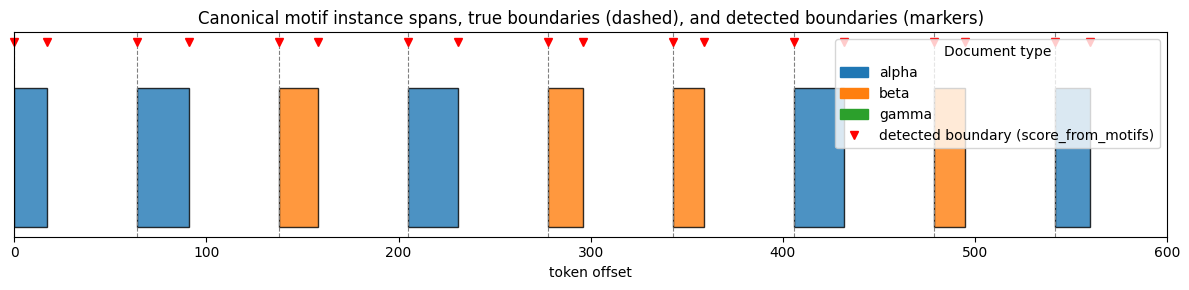

In [7]:
VIEW_END = 600
type_colors = {'alpha': 'tab:blue', 'beta': 'tab:orange', 'gamma': 'tab:green'}

fig, ax = plt.subplots(figsize=(12, 3))

for doc_type, inst in all_instances:
    if inst.start > VIEW_END:
        continue
    ax.barh(0, inst.end - inst.start, left=inst.start, height=0.6,
            color=type_colors[doc_type], edgecolor='black', alpha=0.8)

for t in true_starts:
    if t <= VIEW_END:
        ax.axvline(t, color='gray', linestyle='--', linewidth=0.8)

for b in boundaries:
    if b <= VIEW_END:
        ax.plot(b, 0.5, marker='v', color='red', markersize=6, clip_on=False)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=c, label=t) for t, c in type_colors.items()
]
legend_handles.append(
    plt.Line2D([0], [0], marker='v', color='red', linestyle='None',
               markersize=6, label='detected boundary (score_from_motifs)')
)
ax.legend(handles=legend_handles, loc='upper right', title='Document type')
ax.set_yticks([])
ax.set_xlabel('token offset')
ax.set_title('Canonical motif instance spans, true boundaries (dashed), and detected boundaries (markers)')
ax.set_xlim(0, VIEW_END)
plt.tight_layout()
plt.show()

## 5. Characterising relationships between motifs with `classify_relation`

### 5a. Nested structure: the embedded `stamp` formula inside `alpha`

The two-phrase `stamp` motif should be fully contained within the four-phrase `alpha` motif's span every time it occurs.

In [8]:
stamp_motif = motif_by_set[frozenset(STAMP)]
relation = classify_relation(stamp_motif, canonical_motifs['alpha'], max_gap=40)
print(relation)

MotifRelation(shared=[], dominant='a_nested_in_b' (100% of 14))


`a_nested_in_b` at 100% confirms it: `stamp` is consistently a sub-element nested inside `alpha`, not an independent document-level signal of its own.

### 5b. Sequential sub-parts of the same formula

If we split the `alpha` formula into its first half (`open alpha`, `body one`) and second half (`body two`, `close alpha`), these two smaller motifs should always appear in a fixed sequential order, immediately adjacent &mdash; they're two halves of the same structural unit.

In [9]:
first_half = motif_by_set[frozenset(['open alpha', 'body one'])]
second_half = motif_by_set[frozenset(['body two', 'close alpha'])]
relation = classify_relation(first_half, second_half, max_gap=20)
print(relation)

MotifRelation(shared=[], dominant='a_before_b' (100% of 25))


`a_before_b` at 100% is exactly the signature of two motifs that are really two halves of one larger recurring unit: a consistent, tight, ordered adjacency with no exceptions. (Here we already know this from how the corpus was constructed, but on a real corpus this signature is precisely the evidence that would lead you to consider merging two smaller motifs into one larger one &mdash; which mining directly at size 4 already confirms exists.)

### 5c. Two unrelated document types

As a contrast, compare the `alpha` and `beta` canonical motifs. Since document types are ordered randomly in this corpus, there's no reason to expect any consistent positional relationship between them.

In [10]:
relation = classify_relation(canonical_motifs['alpha'], canonical_motifs['beta'], max_gap=20)
print(relation)

MotifRelation(shared=[], dominant='disjoint_far' (100% of 25))


`disjoint_far` dominates: with `max_gap=20` (smaller than the typical distance between two random, independently-placed documents), most `alpha`/`beta` instance pairs simply aren't close enough to be related at all. This is the correct null result &mdash; it tells you `alpha` and `beta` are two distinct, independent document types rather than parts of the same structure, which is exactly the kind of distinction this method is meant to surface.

## Summary and next steps

* `BoundaryDetector.score_from_motifs` wires `Motif` instance offsets directly into boundary-candidate scoring, recovering all 120 synthetic boundary points (60 document starts + 60 ends) exactly &mdash; using only co-occurrence statistics over a handful of candidate phrases, with no document boundaries ever given to the pipeline.
* `order_entropy` and `lift` on a `Motif` feed directly into the per-instance confidence score (`order_confidence * lift_weight`), so unreliable or weakly significant motifs contribute proportionally less to the final boundary decision rather than needing a separate filtering step.
* `classify_relation` distinguishes nested sub-elements, sequential halves of the same unit (candidates for merging), and genuinely unrelated document types &mdash; useful context before deciding which motifs to pass to `score_from_motifs` in the first place.
* On real data, expect more noise: tune `window` relative to the corpus's typical document length, `min_lift`/`min_support` to filter spurious correlations, and `threshold`/`min_gap` in `detect_boundaries` to match the granularity of boundary you're after (sub-element vs. document-level).
* Because `score_stream` (community-transition based, from `Document-Pattern-Detection.ipynb`) and `score_from_motifs` both emit `(offset, score)` pairs on the same scale, their outputs can simply be concatenated and passed to one `detect_boundaries` call &mdash; combining both sources of evidence when both are available.